In [1]:
#step1: Import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
#step2: load mnist dataset
(x_train,y_train), (x_test,y_test) = keras.datasets.mnist.load_data()

#normalize data
x_train = x_train/255.0
x_test = x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#step3: Build deep neural network model
def create_model():
  model = keras.Sequential([
      layers.Flatten(input_shape = (28,28)),
      layers.Dense(128,activation='relu'),
      layers.Dense(64,activation='relu'),
      layers.Dense(10,activation='softmax')
  ])
  return model

In [4]:
#step4: Train with fixed learning rate
model_fixed = create_model()

optimizer_fixed = keras.optimizers.Adam(learning_rate=0.01)

model_fixed.compile(
    optimizer = optimizer_fixed,
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_fixed = model_fixed.fit(
    x_train,y_train,
    epochs=20,
    validation_split = 0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9185 - loss: 0.2753 - val_accuracy: 0.9480 - val_loss: 0.1870
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9498 - loss: 0.1823 - val_accuracy: 0.9574 - val_loss: 0.1600
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9594 - loss: 0.1532 - val_accuracy: 0.9424 - val_loss: 0.2334
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9614 - loss: 0.1473 - val_accuracy: 0.9477 - val_loss: 0.2185
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9657 - loss: 0.1312 - val_accuracy: 0.9452 - val_loss: 0.2420
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9683 - loss: 0.1202 - val_accuracy: 0.9600 - val_loss: 0.1713
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9701 - loss: 0.1195 - val_accuracy: 0.9500 - val_loss: 0.2375
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9729 - loss: 0.1097 -

In [5]:
#step5: learning rate decay
model_decay = create_model()

lr_schedule = keras.optimizers.schedules.ExponentialDecay (
    initial_learning_rate = 0.1,
    decay_steps = 1000,
    decay_rate = 0.9
)

optimizer_decay = keras.optimizers.Adam(learning_rate = lr_schedule)

model_decay.compile(
    optimizer = optimizer_decay,
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_decay = model_decay.fit(
    x_train,y_train,
    epochs=20,
    validation_split = 0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3063 - loss: 1.8739 - val_accuracy: 0.2988 - val_loss: 1.6549
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2818 - loss: 1.7249 - val_accuracy: 0.2868 - val_loss: 1.6629
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2864 - loss: 1.6750 - val_accuracy: 0.2896 - val_loss: 1.6468
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2951 - loss: 1.6249 - val_accuracy: 0.2880 - val_loss: 1.5849
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2992 - loss: 1.5952 - val_accuracy: 0.2867 - val_loss: 1.5800
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2964 - loss: 1.5961 - val_accuracy: 0.2967 - val_loss: 1.5846
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3006 - loss: 1.5752 - val_accuracy: 0.2898 - val_loss: 1.5899
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2984 - loss: 1.5615 - 

In [6]:
#step6: early stopping
model_early = create_model()

optimizer_early = keras.optimizers.Adam(learning_rate=0.01)

model_early.compile(optimizer=optimizer_early,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,   # stop if no improvement for 3 epochs
    restore_best_weights=True
)

history_early = model_early.fit(x_train, y_train,
                                epochs=20,
                                validation_split=0.2,
                                callbacks=[early_stop],
                                verbose=1)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9188 - loss: 0.2783 - val_accuracy: 0.9503 - val_loss: 0.1787
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9494 - loss: 0.1845 - val_accuracy: 0.9542 - val_loss: 0.1684
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9571 - loss: 0.1567 - val_accuracy: 0.9509 - val_loss: 0.1988
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9617 - loss: 0.1454 - val_accuracy: 0.9563 - val_loss: 0.1758
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9652 - loss: 0.1310 - val_accuracy: 0.9592 - val_loss: 0.1647
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9659 - loss: 0.1338 - val_accuracy: 0.9606 - val_loss: 0.1791
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9712 - loss: 0.1133 - val_accuracy: 0.9632 - val_loss: 0.1952
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9729 - loss: 0.1085 -

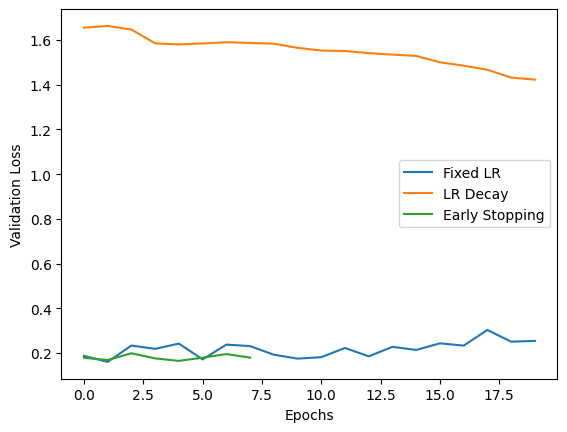

In [7]:
#step7 : Plotting the graphs
plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_decay.history['val_loss'], label='LR Decay')
plt.plot(history_early.history['val_loss'], label='Early Stopping')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [8]:
#step8:compare epochs
print("Fixed LR epochs:", len(history_fixed.history['loss']))
print("LR Decay epochs:", len(history_decay.history['loss']))
print("Early Stopping epochs:", len(history_early.history['loss']))


Fixed LR epochs: 20
LR Decay epochs: 20
Early Stopping epochs: 8
